Hidden Units:   2 | Training Accuracy: 66.25% | Testing Accuracy: 66.67%
Hidden Units:   4 | Training Accuracy: 93.75% | Testing Accuracy: 91.67%
Hidden Units:   8 | Training Accuracy: 98.33% | Testing Accuracy: 100.00%
Hidden Units:  16 | Training Accuracy: 99.58% | Testing Accuracy: 100.00%
Hidden Units:  32 | Training Accuracy: 100.00% | Testing Accuracy: 100.00%
Hidden Units:  64 | Training Accuracy: 100.00% | Testing Accuracy: 100.00%
Hidden Units: 128 | Training Accuracy: 100.00% | Testing Accuracy: 100.00%


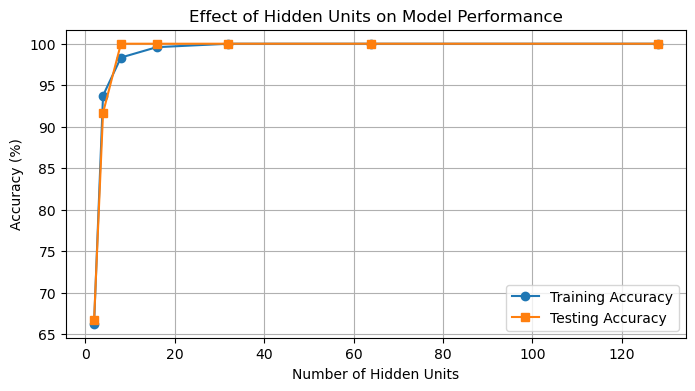

In [1]:
# Hidden Units and Model Capacity
# Multi-Class Student Performance Classification

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reproducibility
np.random.seed(0)
torch.manual_seed(0)

# --------------------------------------------------
# 1. Generate synthetic student performance data
# --------------------------------------------------

num_samples_per_class = 100

low = np.column_stack((
    np.random.normal(2.0, 0.6, num_samples_per_class),
    np.random.normal(55, 8, num_samples_per_class),
    np.random.normal(50, 12, num_samples_per_class),
    np.random.normal(50, 8, num_samples_per_class)
))

medium = np.column_stack((
    np.random.normal(4.0, 0.7, num_samples_per_class),
    np.random.normal(75, 7, num_samples_per_class),
    np.random.normal(65, 12, num_samples_per_class),
    np.random.normal(72, 6, num_samples_per_class)
))

high = np.column_stack((
    np.random.normal(6.5, 0.8, num_samples_per_class),
    np.random.normal(90, 5, num_samples_per_class),
    np.random.normal(80, 12, num_samples_per_class),
    np.random.normal(90, 5, num_samples_per_class)
))

data = np.vstack((low, medium, high)).astype(np.float32)

labels = np.hstack((
    np.zeros(num_samples_per_class),
    np.ones(num_samples_per_class),
    np.full(num_samples_per_class, 2)
)).astype(np.int64)

# --------------------------------------------------
# 2. Train/test split and standardization
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# --------------------------------------------------
# 3. Function to build ANN with variable hidden units
# --------------------------------------------------

def build_model(hidden_units):
    model = nn.Sequential(
        nn.Linear(4, hidden_units),
        nn.ReLU(),
        nn.Linear(hidden_units, hidden_units),
        nn.ReLU(),
        nn.Linear(hidden_units, 3)
    )
    return model

# --------------------------------------------------
# 4. Function to train and evaluate model
# --------------------------------------------------

def train_model(hidden_units, num_epochs=300):

    model = build_model(hidden_units)

    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    training_losses = []
    training_accuracies = []
    testing_accuracies = []

    for epoch in range(num_epochs):

        model.train()

        train_outputs = model(X_train)
        loss = loss_function(train_outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_predictions = torch.argmax(train_outputs, dim=1)
        train_accuracy = (
            train_predictions == y_train
        ).float().mean() * 100

        model.eval()

        with torch.no_grad():

            test_outputs = model(X_test)

            test_predictions = torch.argmax(
                test_outputs,
                dim=1
            )

            test_accuracy = (
                test_predictions == y_test
            ).float().mean() * 100

        training_losses.append(loss.item())
        training_accuracies.append(train_accuracy.item())
        testing_accuracies.append(test_accuracy.item())

    return {
        "hidden_units": hidden_units,
        "model": model,
        "training_losses": training_losses,
        "training_accuracies": training_accuracies,
        "testing_accuracies": testing_accuracies,
        "final_train_accuracy": training_accuracies[-1],
        "final_test_accuracy": testing_accuracies[-1]
    }

# --------------------------------------------------
# 5. Train models with different hidden units
# --------------------------------------------------

hidden_unit_options = [2, 4, 8, 16, 32, 64, 128]

results = []

for hidden_units in hidden_unit_options:

    result = train_model(hidden_units)

    results.append(result)

    print(
        f"Hidden Units: {hidden_units:3d} | "
        f"Training Accuracy: {result['final_train_accuracy']:.2f}% | "
        f"Testing Accuracy: {result['final_test_accuracy']:.2f}%"
    )

# --------------------------------------------------
# 6. Compare final accuracy
# --------------------------------------------------

train_acc = [
    result["final_train_accuracy"]
    for result in results
]

test_acc = [
    result["final_test_accuracy"]
    for result in results
]

plt.figure(figsize=(8, 4))

plt.plot(hidden_unit_options, train_acc, "o-", label="Training Accuracy")
plt.plot(hidden_unit_options, test_acc, "s-", label="Testing Accuracy")

plt.xlabel("Number of Hidden Units")
plt.ylabel("Accuracy (%)")
plt.title("Effect of Hidden Units on Model Performance")
plt.legend()
plt.grid(True)

plt.show()


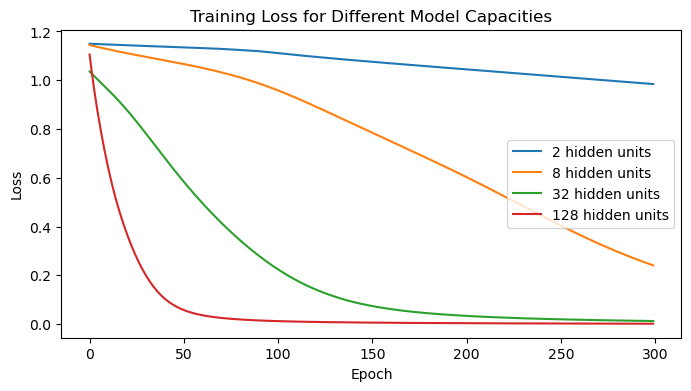

In [2]:
# --------------------------------------------------
# 7. Plot loss curves for selected models
# --------------------------------------------------

plt.figure(figsize=(8, 4))

for result in results:

    if result["hidden_units"] in [2, 8, 32, 128]:

        plt.plot(
            result["training_losses"],
            label=f"{result['hidden_units']} hidden units"
        )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss for Different Model Capacities")
plt.legend()

plt.show()